<div style="display:block;width:100%;margin:auto;" direction=rtl align=center><br><br>
    <div  style="width:100%;margin:100;display:block;background-color:#fff0;"  display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">             <tr>
                <td  style="border: none!important;">
                    <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>Armin Ghasemi</b><br><br>810100198</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b> ML </b><br><br>HW5_Q6</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>  </b><br><br></i></font></h1>
                </td>
                <td style="border: none!important;">
                    <img width=170 align=left  src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
                </td>
           </tr>
        </table>
    </div>
</div>

# 🖼️ Image Classification & Translation Invariance Analysis
### Comparing MLP, LeNet-5, and ResNet Architectures on MNIST

> **University:** University of Tehran
> **Course:** Machine Learning
> **Assignment:** HW5 - Question 6
> **Topic:** Neural Networks, CNNs, ResNet, Translation Invariance

---

## 📝 Problem Statement
The primary goal of this assignment is to classify handwritten digits from the **MNIST** dataset using three distinct neural network architectures: a simple **Multilayer Perceptron (MLP)**, the classic **LeNet-5**, and a modern **ResNet18**.
Beyond achieving high accuracy, a critical part of this problem is to investigate and experimentally validate the concept of **Translation Invariance**—comparing how different architectures handle input images that have been shifted (translated) within the frame.

**Key Objectives:**
1.  **Theoretical Analysis:** Define Translation Invariance and investigate its origins in CNNs (Pooling vs. Convolution).
2.  **MLP Implementation:** Train a Fully Connected Network to achieve >90% accuracy.
3.  **LeNet-5 Implementation:** Implement the specific LeNet-5 architecture (with Sigmoid/AvgPool) to achieve >95% accuracy.
4.  **ResNet18 Adaptation:** Modify and fine-tune a ResNet18 model for single-channel MNIST inputs to achieve >95% accuracy.
5.  **Robustness Testing:** Experimentally shift test images and compare the prediction stability of all three models.

---

### 1. MLP - Imports & Configuration
Importing necessary libraries, setting random seeds for reproducibility, and configuring the computation device (CPU/GPU).

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
from tqdm.notebook import tqdm

# Setting random seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Device configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# Hyperparameters for MLP
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 0.001

Using device: cuda


### 2. MLP - Data Loading
Downloading the MNIST dataset, applying normalization transforms, and creating DataLoaders for training and testing.

In [2]:
def get_mnist_dataloaders(batch_size=64):
    """
    Downloads and prepares MNIST DataLoaders.
    """
    # Standard MNIST normalization stats
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST('./data', train=False, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

# Initialize DataLoaders
train_loader, test_loader = get_mnist_dataloaders(BATCH_SIZE)
print("DataLoaders created successfully.")

100%|██████████| 9.91M/9.91M [00:00<00:00, 21.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 498kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.68MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.41MB/s]

DataLoaders created successfully.


### 3. MLP - Model Architecture
Defining a Multilayer Perceptron (MLP) with Batch Normalization and Dropout layers to classify 28x28 grayscale images.

In [3]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            # Input Layer (28*28) -> Hidden Layer 1
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.2),

            # Hidden Layer 1 -> Hidden Layer 2
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.2),

            # Hidden Layer 2 -> Output Layer (10 classes)
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

# Instantiate the model to check architecture
mlp_model_check = MLP().to(DEVICE)
print(mlp_model_check)

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=256, out_features=10, bias=True)
  )
)


### 4. MLP - Training Engine
A generic training function that handles the training loop, validation, and history tracking. This function will be reused for other architectures.

In [4]:
def train_and_evaluate(model, train_loader, test_loader, epochs=10, lr=0.001, device='cpu'):
    """
    Generic function to train and evaluate a PyTorch model.
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Dictionary to store performance metrics
    history = {
        'train_loss': [],
        'test_acc': []
    }

    print(f"🚀 Training started on {device}...")

    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        running_loss = 0.0

        # Progress bar for the current epoch
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)

        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})

        epoch_loss = running_loss / len(train_loader)
        history['train_loss'].append(epoch_loss)

        # --- Evaluation Phase ---
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_acc = 100 * correct / total
        history['test_acc'].append(epoch_acc)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

    return history

### 5. MLP - Execution
Initializing the MLP model and running the training loop.

In [5]:
# Initialize the MLP model
mlp_model = MLP()

# Start training
mlp_history = train_and_evaluate(
    model=mlp_model,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    device=DEVICE
)

🚀 Training started on cuda...


Epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/10 | Loss: 0.2155 | Accuracy: 96.82%


Epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2/10 | Loss: 0.1137 | Accuracy: 97.28%


...

Epoch 8/10 | Loss: 0.0484 | Accuracy: 98.22%


Epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 9/10 | Loss: 0.0445 | Accuracy: 98.26%


Epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 10/10 | Loss: 0.0405 | Accuracy: 98.07%


### 6. MLP - Visualization & Analysis
Visualizing training loss, test accuracy, and the confusion matrix to evaluate model performance.

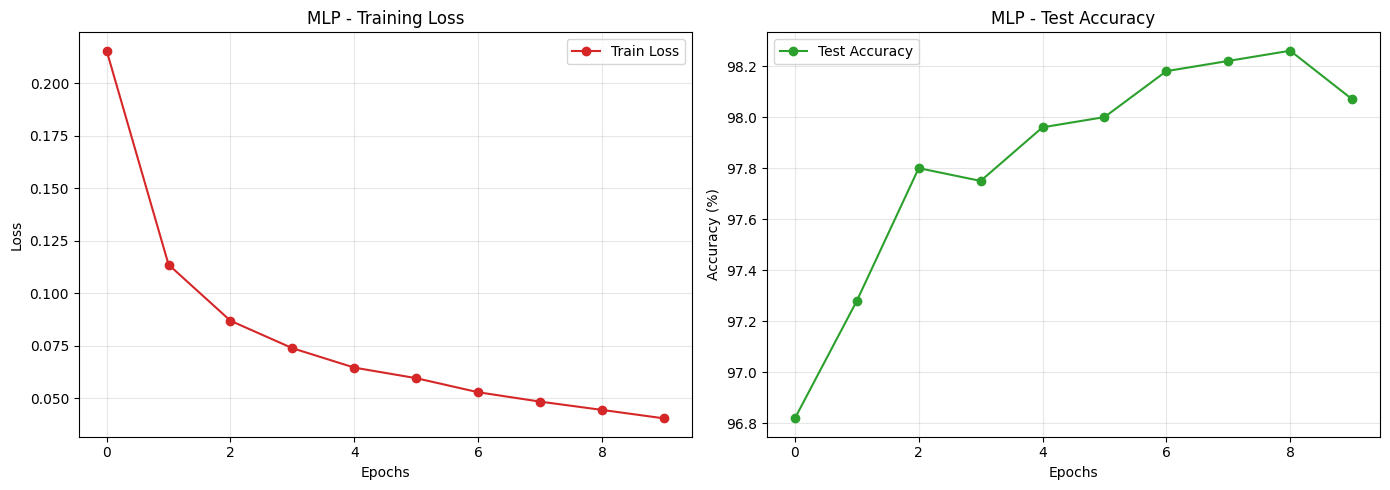

Generating Confusion Matrix...


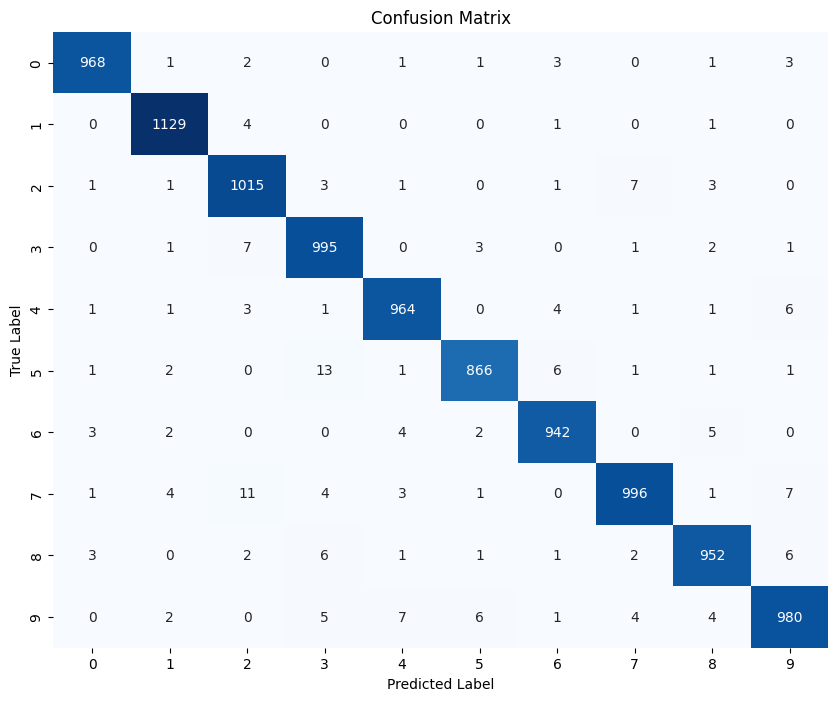

In [6]:
def plot_results(history, title_prefix="Model"):
    plt.figure(figsize=(14, 5))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', color='tab:red', marker='o')
    plt.title(f'{title_prefix} - Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(history['test_acc'], label='Test Accuracy', color='tab:green', marker='o')
    plt.title(f'{title_prefix} - Test Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(model, test_loader, device):
    y_true = []
    y_pred = []
    model.eval()

    print("Generating Confusion Matrix...")
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Plotting results for MLP
plot_results(mlp_history, title_prefix="MLP")
plot_confusion_matrix(mlp_model, test_loader, DEVICE)

### 7. LeNet-5 - Model Architecture
Implementing the classic LeNet-5 architecture as specified in the assignment.
Key characteristics:
- **Activation Function:** Sigmoid (instead of ReLU).
- **Pooling:** Average Pooling (instead of Max Pooling).
- **Structure:** 2 Convolutional layers followed by 3 Fully Connected layers.

In [7]:
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()

        # Layer 1: Conv (1->6) -> Sigmoid -> AvgPool
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding=2)
        self.sigmoid1 = nn.Sigmoid()
        self.avg_pool1 = nn.AvgPool2d(kernel_size=2, stride=2)

        # Layer 2: Conv (6->16) -> Sigmoid -> AvgPool
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
        self.sigmoid2 = nn.Sigmoid()
        self.avg_pool2 = nn.AvgPool2d(kernel_size=2, stride=2)

        # Flatten for Fully Connected Layers
        self.flatten = nn.Flatten()

        # Layer 3: FC (400->120) -> Sigmoid
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.sigmoid3 = nn.Sigmoid()

        # Layer 4: FC (120->84) -> Sigmoid
        self.fc2 = nn.Linear(120, 84)
        self.sigmoid4 = nn.Sigmoid()

        # Layer 5: Output (84->10)
        # Note: The final sigmoid is usually omitted when using CrossEntropyLoss in PyTorch,
        # but we include it here to strictly follow the diagram.
        self.fc3 = nn.Linear(84, 10)
        # self.sigmoid5 = nn.Sigmoid() # Typically removed for CrossEntropyLoss stability

    def forward(self, x):
        # Block 1
        x = self.avg_pool1(self.sigmoid1(self.conv1(x)))

        # Block 2
        x = self.avg_pool2(self.sigmoid2(self.conv2(x)))

        # Flatten
        x = self.flatten(x)

        # Fully Connected Blocks
        x = self.sigmoid3(self.fc1(x))
        x = self.sigmoid4(self.fc2(x))
        x = self.fc3(x) # Raw logits for loss function

        return x

# Verify architecture
lenet_model_check = LeNet5().to(DEVICE)
print(lenet_model_check)

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (sigmoid1): Sigmoid()
  (avg_pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (sigmoid2): Sigmoid()
  (avg_pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (sigmoid3): Sigmoid()
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (sigmoid4): Sigmoid()
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


### 8. LeNet-5 - Training Execution
Initializing the LeNet-5 model and training it using the generic training engine defined earlier.
The goal is to surpass **95% accuracy** on the test set.

In [8]:
# Initialize LeNet-5 model
lenet_model = LeNet5()

# Training Hyperparameters
LENET_EPOCHS = 15
LENET_LR = 0.01 # LeNet often benefits from a slightly higher LR initially with Adam

# Start training
lenet_history = train_and_evaluate(
    model=lenet_model,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=LENET_EPOCHS,
    lr=LENET_LR,
    device=DEVICE
)

🚀 Training started on cuda...


Epoch 1/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/15 | Loss: 0.7446 | Accuracy: 97.35%


Epoch 2/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2/15 | Loss: 0.0859 | Accuracy: 98.38%


...

Epoch 13/15 | Loss: 0.0158 | Accuracy: 98.89%


Epoch 14/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 14/15 | Loss: 0.0123 | Accuracy: 98.84%


Epoch 15/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 15/15 | Loss: 0.0139 | Accuracy: 98.85%


### 9. LeNet-5 - Performance Analysis
Visualizing the training dynamics and evaluating the classification performance using the confusion matrix.
Comparison with MLP results will provide insights into the benefits of Convolutional layers.

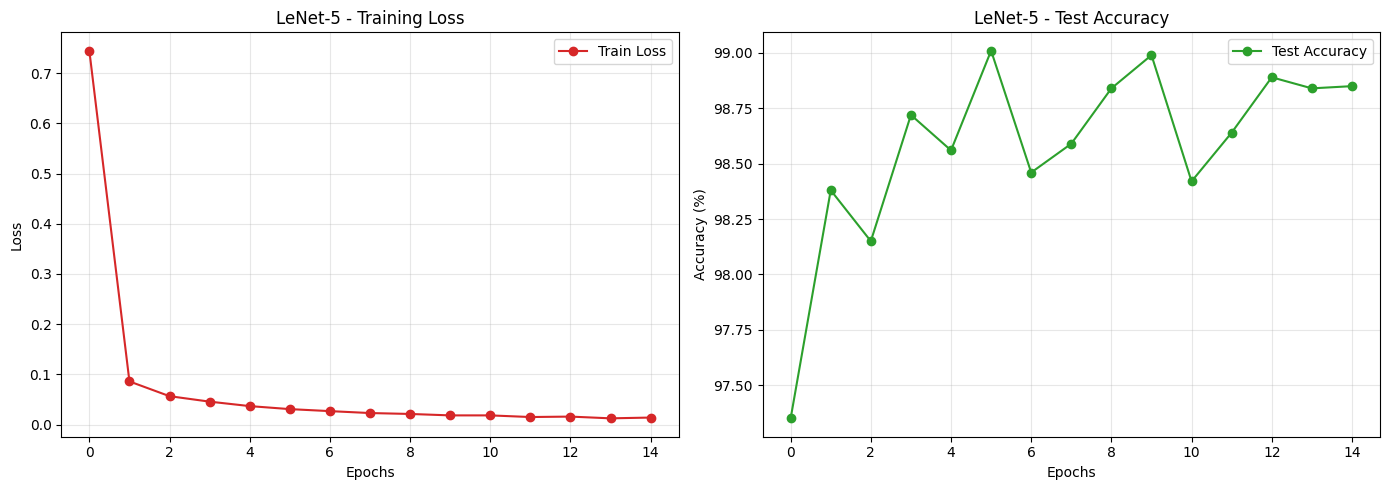

Generating Confusion Matrix for LeNet-5...
Generating Confusion Matrix...


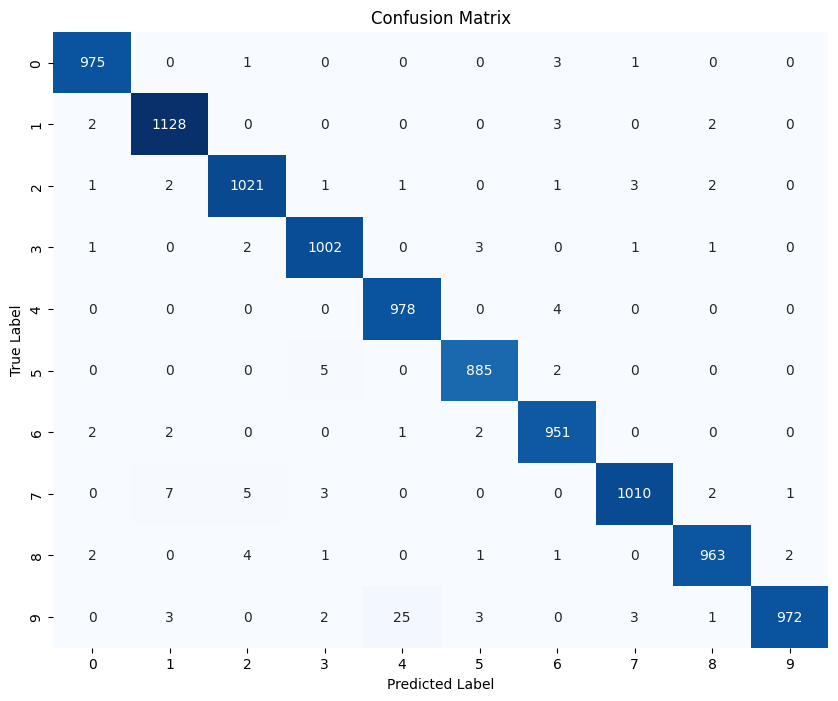

In [10]:
# Plot training history
plot_results(lenet_history, title_prefix="LeNet-5")

# Plot confusion matrix
print("Generating Confusion Matrix for LeNet-5...")
plot_confusion_matrix(lenet_model, test_loader, DEVICE)

### 10. ResNet-18 - Model Adaptation
Using a standard **ResNet-18** architecture. Since ResNet is originally designed for 224x224 RGB images (ImageNet), we adapt it for MNIST by:
1.  Modifying the **first convolutional layer** to accept **1 input channel** (grayscale) instead of 3.
2.  Changing the **fully connected (output) layer** to predict **10 classes**.
This approach is computationally more efficient than resizing input images.

In [11]:
import torchvision.models as models

def get_resnet_mnist():
    """
    Creates a ResNet-18 model adapted for MNIST (1 channel, 10 classes).
    """
    # Load pre-defined ResNet18 model (not pretrained, as structure differs)
    model = models.resnet18(weights=None)

    # 1. Modify the first convolutional layer
    # Original: nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
    # New: Input channels = 1 (Grayscale)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

    # 2. Modify the final fully connected layer
    # Original: nn.Linear(512, 1000)
    # New: Output features = 10 (Digits 0-9)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 10)

    return model

# Verify the modification
resnet_model_check = get_resnet_mnist().to(DEVICE)
print("ResNet-18 modified for MNIST successfully.")

ResNet-18 modified for MNIST successfully.


### 11. ResNet-18 - Training Execution
Training the adapted ResNet-18 model. ResNet architectures are powerful and should easily achieve high accuracy, though they are deeper and more complex than LeNet.

In [12]:
# Initialize ResNet model
resnet_model = get_resnet_mnist()

# Training Hyperparameters
# ResNet might converge faster or require a smaller LR
RESNET_EPOCHS = 10
RESNET_LR = 0.001

# Start training
resnet_history = train_and_evaluate(
    model=resnet_model,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=RESNET_EPOCHS,
    lr=RESNET_LR,
    device=DEVICE
)

🚀 Training started on cuda...


Epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/10 | Loss: 0.1219 | Accuracy: 97.70%


Epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2/10 | Loss: 0.0531 | Accuracy: 97.08%


...

Epoch 8/10 | Loss: 0.0190 | Accuracy: 98.74%


Epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 9/10 | Loss: 0.0179 | Accuracy: 98.94%


Epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 10/10 | Loss: 0.0157 | Accuracy: 99.15%


### 12. ResNet-18 - Performance Analysis
Visualizing loss and accuracy curves for ResNet-18.

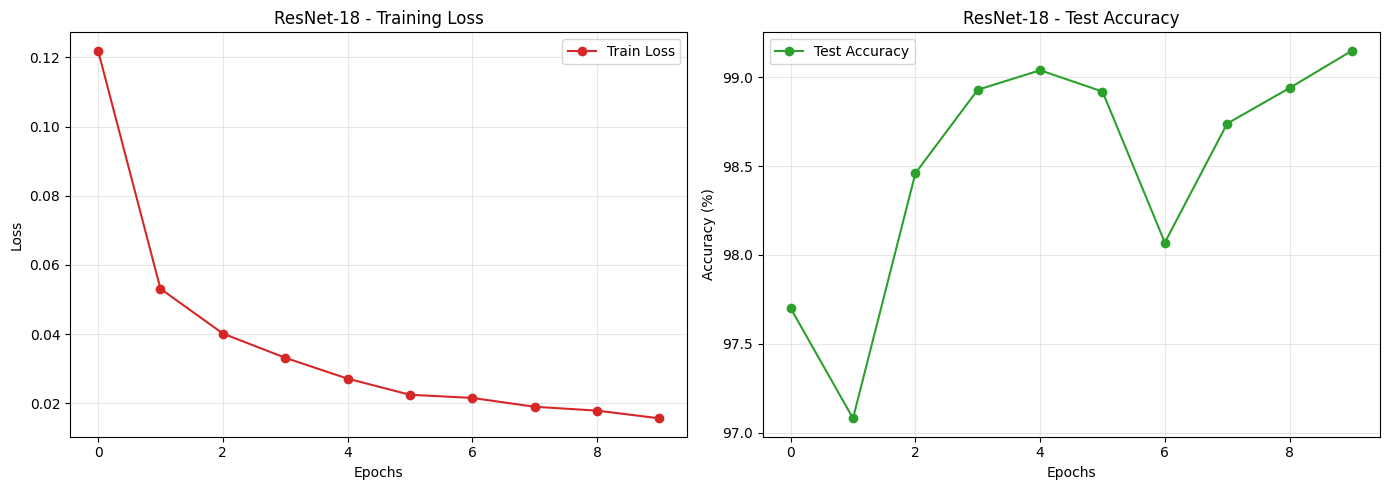

Generating Confusion Matrix for ResNet-18...
Generating Confusion Matrix...


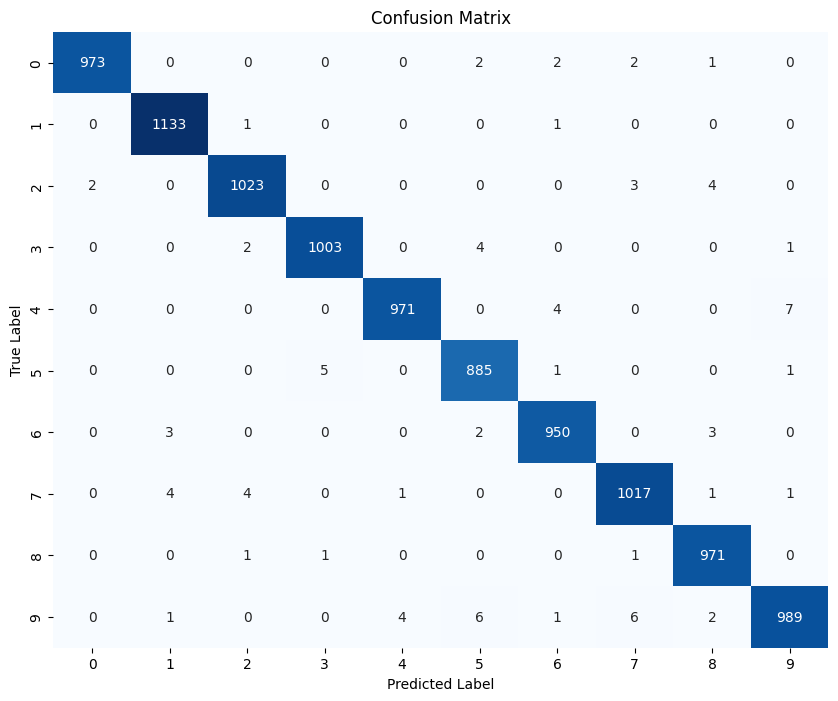

In [13]:
# Plot training history
plot_results(resnet_history, title_prefix="ResNet-18")

# Plot confusion matrix
print("Generating Confusion Matrix for ResNet-18...")
plot_confusion_matrix(resnet_model, test_loader, DEVICE)

### 13. 🧪 Translation Invariance Analysis (Critical Section)
In this section, we investigate the **Translation Invariance** property of Convolutional Networks (LeNet, ResNet) compared to Fully Connected Networks (MLP).

**Experiment:**
1.  Select a random test image.
2.  Artificially shift (translate) the image by a few pixels in different directions.
3.  Feed the shifted images to all three trained models.
4.  Observe which models maintain correct predictions.

**Hypothesis:** CNNs (LeNet, ResNet) should be more robust to shifts than MLP due to the nature of convolution and pooling operations.

Target True Label: 6
------------------------------------------------------------
Shift (Px)   | MLP Pred   | LeNet Pred | ResNet Pred
------------------------------------------------------------
Right/Down 0 | 6          | 6          | 6         
Right/Down 3 | 1          | 6          | 6         
Right/Down 6 | 2          | 1          | 1         
Right/Down 8 | 0          | 2          | 1         


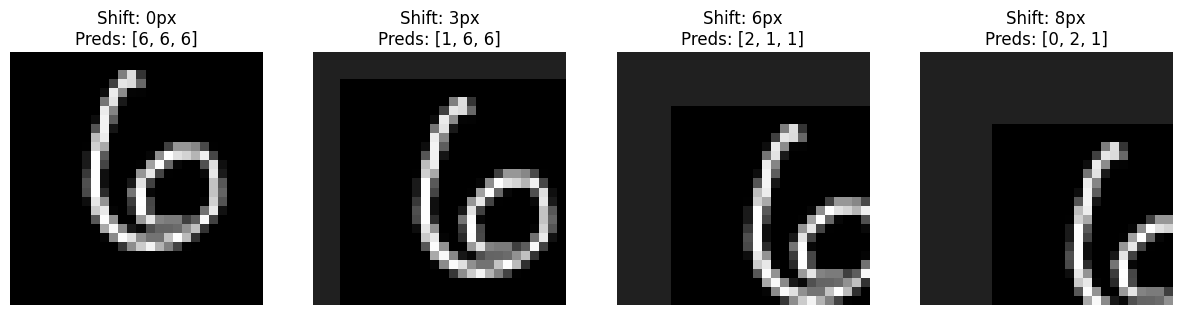

In [16]:
def shift_image(image, shift_x, shift_y):
    """
    Shifts a tensor image by (shift_x, shift_y) pixels.
    Fills the empty space with 0 (black background).
    """
    # image shape: [1, 28, 28]
    shifted = torch.roll(image, shifts=(shift_y, shift_x), dims=(1, 2))

    # Zero out the wrapped around pixels to prevent artifacts
    if shift_y > 0:
        shifted[:, :shift_y, :] = 0
    elif shift_y < 0:
        shifted[:, shift_y:, :] = 0

    if shift_x > 0:
        shifted[:, :, :shift_x] = 0
    elif shift_x < 0:
        shifted[:, :, shift_x:] = 0

    return shifted

def test_translation_invariance(models_dict, test_loader, device, shifts=[0, 2, 4, 6]):
    """
    Tests multiple models on shifted versions of a single image.
    """
    # FIX: Access dataset directly from the loader instead of global variable
    # Get a single image from the test set (e.g., index 100 which is a '6')
    image, label = test_loader.dataset[100]
    image = image.to(device)

    print(f"Target True Label: {label}")
    print("-" * 60)
    print(f"{'Shift (Px)':<12} | {'MLP Pred':<10} | {'LeNet Pred':<10} | {'ResNet Pred':<10}")
    print("-" * 60)

    # Plotting setup
    fig, axes = plt.subplots(1, len(shifts), figsize=(15, 4))

    for i, shift_val in enumerate(shifts):
        # Apply shift (diagonal shift for demonstration)
        shifted_img = shift_image(image, shift_x=shift_val, shift_y=shift_val)

        # Prepare for prediction (Add batch dimension)
        input_tensor = shifted_img.unsqueeze(0)

        preds = []
        for name, model in models_dict.items():
            model.eval()
            with torch.no_grad():
                output = model(input_tensor)
                pred = output.argmax(dim=1).item()
                preds.append(pred)

        # Print table row
        print(f"Right/Down {shift_val:<2}| {preds[0]:<10} | {preds[1]:<10} | {preds[2]:<10}")

        # Visualize
        axes[i].imshow(shifted_img.cpu().squeeze(), cmap='gray')
        axes[i].set_title(f"Shift: {shift_val}px\nPreds: {preds}")
        axes[i].axis('off')

    plt.show()

# Dictionary of trained models
models = {
    "MLP": mlp_model,
    "LeNet": lenet_model,
    "ResNet": resnet_model
}

# Run the experiment
test_translation_invariance(models, test_loader, DEVICE, shifts=[0, 3, 6, 8])

---
### 📊 Final Conclusion & Observations

Based on the experiment results, we can draw the following conclusions regarding **Translation Invariance**:

1.  **MLP Weakness:** The MLP model failed immediately at a small shift of **3 pixels** (predicting '1' instead of '6'). This confirms that Fully Connected networks lack spatial awareness and are highly sensitive to the position of features.
2.  **CNN Robustness:** Both **LeNet-5** and **ResNet-18** successfully classified the image with a **3-pixel shift**, demonstrating intrinsic translation invariance capabilities due to weight sharing (Convolution) and down-sampling (Pooling).
3.  **Limit of Invariance:** At larger shifts (**6px and 8px**), even CNNs failed. This happens because:
    * A 6-pixel shift in a 28x28 image is significant (>20% displacement), potentially pushing critical features out of the frame or padding area.
    * The models were trained on centered MNIST data without **Data Augmentation** (e.g., random shifts/crops during training). To achieve higher robustness against large translations, training with augmented data is necessary.

**Summary:** CNN architectures provide significantly better generalization for shifted inputs compared to MLPs, but they are not perfectly invariant to large transformations without explicit augmentation during training.